# 01 – Data Preparation & Exploration
**Project:** AI Football Event Classifier (CNN) — Yannick Maas  
**Dataset:** [Soccer View and Event Score](https://www.kaggle.com/datasets/fahadahmedkhokhar/soccer-view-and-event-score)

The Kaggle dataset is organised as **two independent single-label tasks**:

```
<DATASET_ROOT>/
├── EventClasses/
│   ├── corner/        *.jpg
│   ├── freekick/      *.jpg
│   ├── gattempts/     *.jpg
│   ├── goal/          *.jpg
│   ├── offside/       *.jpg
│   ├── playercelebration/ *.jpg
│   ├── plentystock/   *.jpg
│   ├── redc/          *.jpg
│   ├── spectator/     *.jpg
│   └── yellowcard/    *.jpg
└── ViewClasses/
    ├── MediumView/    *.jpg
    ├── OuterView/     *.jpg
    ├── ShotView/      *.jpg
    └── longView/      *.jpg
```

Each image lives **directly inside one class folder** (one level deep, not nested
event/view). This notebook walks both trees, builds a manifest per task, and
saves a combined `manifest.csv` so the downstream training notebooks can
classify the actual event (goal, yellowcard, freekick, …) and the camera view.

> ⚠️ Limited to **`MAX_PER_CLASS`** images per class to keep runtime manageable.


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import random
import csv
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

random.seed(42)
np.random.seed(42)

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
# DATASET_ROOT must point to the folder that contains EventClasses/ and ViewClasses/.
DATASET_ROOT = Path('C:\\Users\\Yannick\\data\\soccer')   # ← change if needed
EVENT_ROOT   = DATASET_ROOT / 'EventClasses'
VIEW_ROOT    = DATASET_ROOT / 'ViewClasses'

OUTPUT_DIR   = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

IMG_SIZE      = (224, 224)
MAX_PER_CLASS = 300        # max images per individual class folder
IMG_EXTS      = ('*.jpg', '*.jpeg', '*.png')

print(f'Dataset root : {DATASET_ROOT.resolve()}')
print(f'Event root   : {EVENT_ROOT}')
print(f'View  root   : {VIEW_ROOT}')
print(f'Image size   : {IMG_SIZE}')
print(f'Max per class: {MAX_PER_CLASS}')

Dataset root : C:\Users\Yannick\data\soccer
Event root   : C:\Users\Yannick\data\soccer\EventClasses
View  root   : C:\Users\Yannick\data\soccer\ViewClasses
Image size   : (224, 224)
Max per class: 150


In [3]:
# ── 1. Walk EventClasses/ and ViewClasses/ ───────────────────────────────────
def scan_task(root: Path, task_name: str) -> pd.DataFrame:
    if not root.exists():
        raise FileNotFoundError(f'{root} does not exist. Check DATASET_ROOT.')
    rows = []
    for class_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        files = []
        for ext in IMG_EXTS:
            files.extend(class_dir.glob(ext))
        for fp in files:
            rows.append({'path': str(fp), 'task': task_name, 'label': class_dir.name})
    df = pd.DataFrame(rows)
    print(f'{task_name:6s}: {len(df):>6,} images across {df["label"].nunique()} classes '
          f'→ {sorted(df["label"].unique())}')
    return df

df_events = scan_task(EVENT_ROOT, 'event')
df_views  = scan_task(VIEW_ROOT,  'view')

df_all = pd.concat([df_events, df_views], ignore_index=True)
print(f'\nTotal images (event + view): {len(df_all):,}')
df_all.head()

event : 38,728 images across 10 classes → ['corner', 'freekick', 'gattempts', 'goal', 'offside', 'playercelebration', 'plentystock', 'redc', 'spectator', 'yellowcard']
view  : 99,717 images across 4 classes → ['MediumView', 'OuterView', 'ShotView', 'longView']

Total images (event + view): 138,445


,path,task,label
0,C:\Users\Yannick\data\soccer\EventClasses\corn...,event,corner
1,C:\Users\Yannick\data\soccer\EventClasses\corn...,event,corner
2,C:\Users\Yannick\data\soccer\EventClasses\corn...,event,corner
3,C:\Users\Yannick\data\soccer\EventClasses\corn...,event,corner
4,C:\Users\Yannick\data\soccer\EventClasses\corn...,event,corner


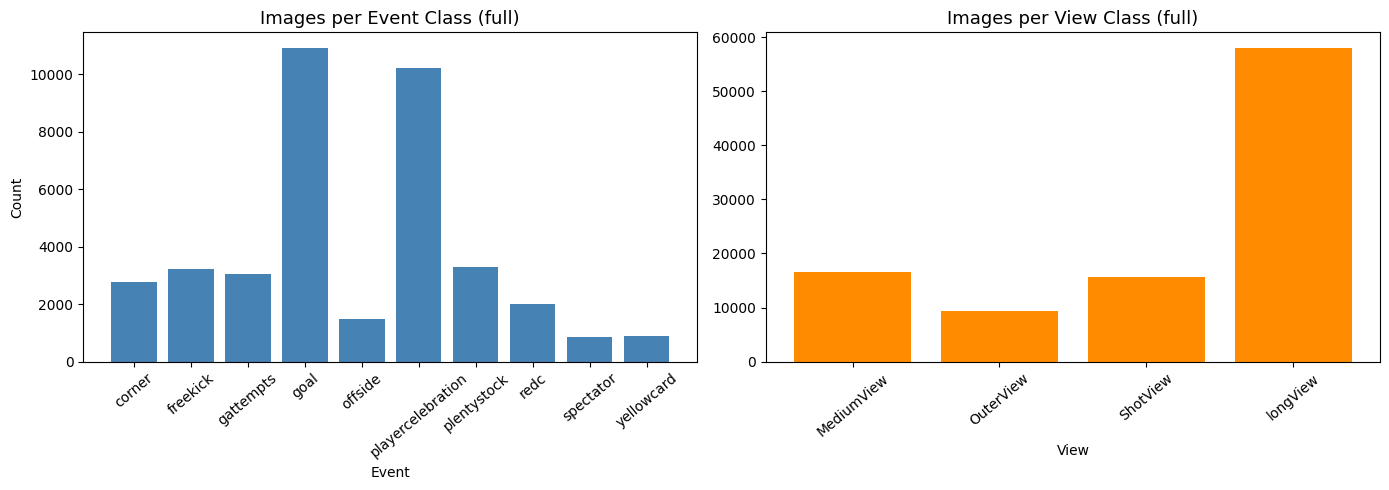

Saved → outputs/class_distribution.png


In [4]:
# ── 2. Class distribution plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ev_counts = df_events['label'].value_counts().sort_index()
axes[0].bar(ev_counts.index, ev_counts.values, color='steelblue')
axes[0].set_title('Images per Event Class (full)', fontsize=13)
axes[0].set_xlabel('Event')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40)

vw_counts = df_views['label'].value_counts().sort_index()
axes[1].bar(vw_counts.index, vw_counts.values, color='darkorange')
axes[1].set_title('Images per View Class (full)', fontsize=13)
axes[1].set_xlabel('View')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=120)
plt.show()
print('Saved → outputs/class_distribution.png')

In [5]:
# ── 3. Sample a balanced subset (per class, per task) ─────────────────────────
def balanced_sample(df: pd.DataFrame, max_per_class: int) -> pd.DataFrame:
    parts = []
    for label, grp in df.groupby('label'):
        n = min(len(grp), max_per_class)
        parts.append(grp.sample(n, random_state=42))
    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1, random_state=42).reset_index(drop=True)

df_events_s = balanced_sample(df_events, MAX_PER_CLASS)
df_views_s  = balanced_sample(df_views,  MAX_PER_CLASS)
df = pd.concat([df_events_s, df_views_s], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Event subset: {len(df_events_s):,}')
print(f'View  subset: {len(df_views_s):,}')
print(f'Combined    : {len(df):,}\n')
print('Per-class counts:')
print(df.groupby(['task', 'label']).size().to_string())

Event subset: 1,500
View  subset: 600
Combined    : 2,100

Per-class counts:
task   label            
event  corner               150
       freekick             150
       gattempts            150
       goal                 150
       offside              150
       playercelebration    150
       plentystock          150
       redc                 150
       spectator            150
       yellowcard           150
view   MediumView           150
       OuterView            150
       ShotView             150
       longView             150


In [6]:
# ── 4. Verify images & collect basic stats ────────────────────────────────────
broken, widths, heights = [], [], []
for path in df['path']:
    try:
        with Image.open(path) as img:
            widths.append(img.width); heights.append(img.height)
    except Exception:
        broken.append(path)

print(f'Broken / unreadable images: {len(broken)}')
print(f'Width  — min:{min(widths)}, max:{max(widths)}, mean:{int(np.mean(widths))}')
print(f'Height — min:{min(heights)}, max:{max(heights)}, mean:{int(np.mean(heights))}')

if broken:
    df = df[~df['path'].isin(broken)].reset_index(drop=True)
    print(f'Removed broken → {len(df):,} remain')

Broken / unreadable images: 0
Width  — min:540, max:1280, mean:878
Height — min:352, max:720, mean:495


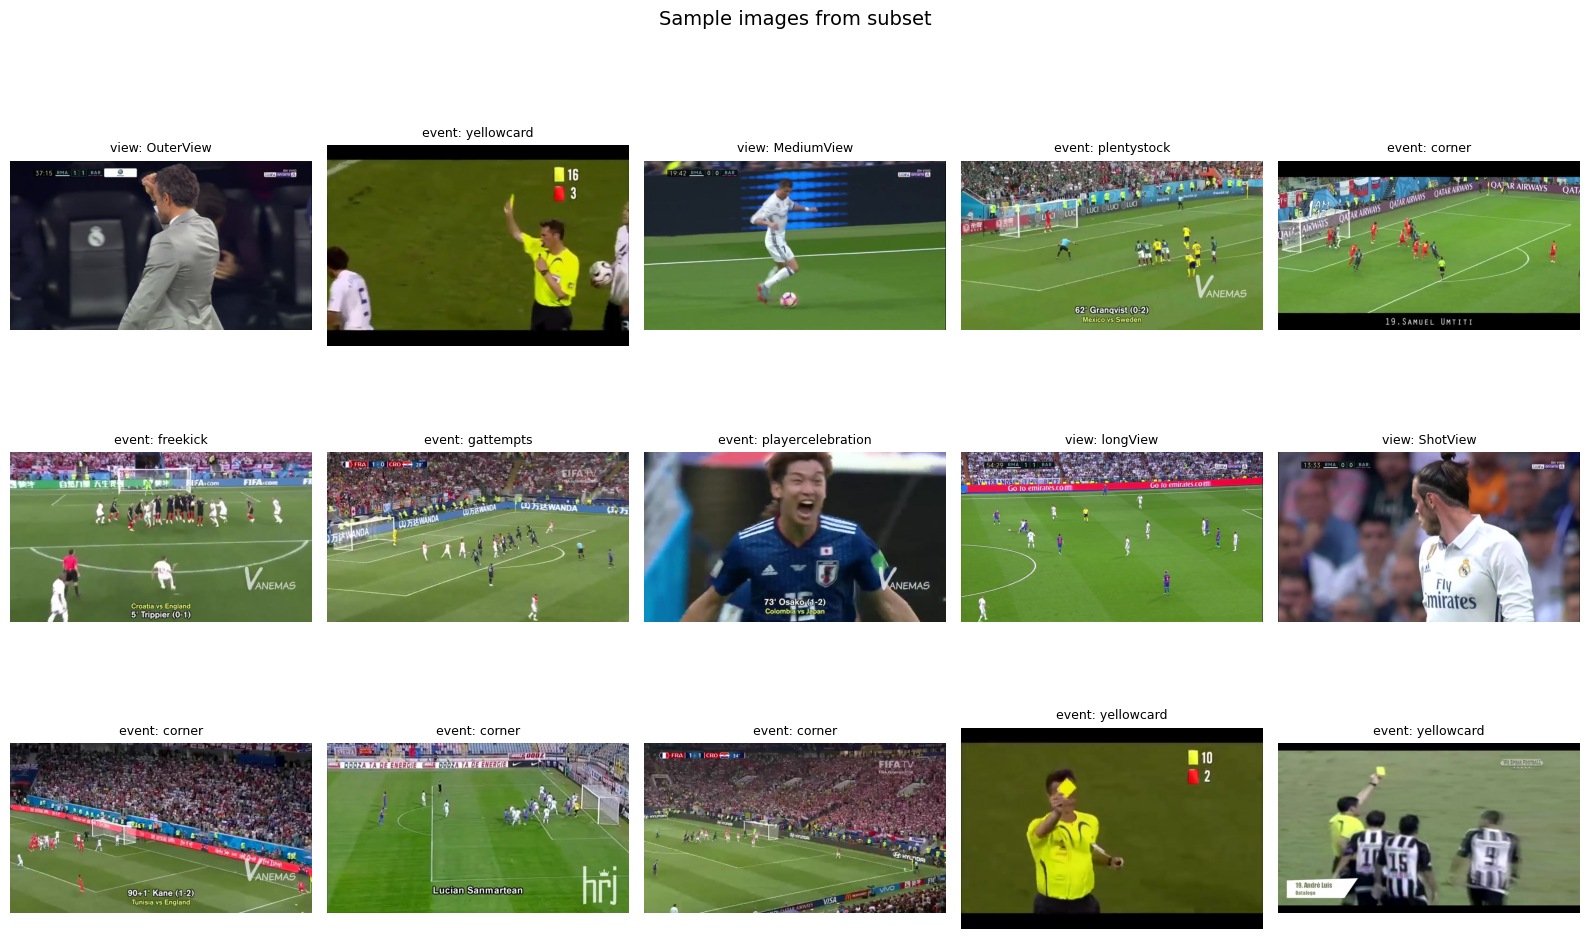

Saved → outputs/sample_images.png


In [7]:
# ── 5. Visualise sample images ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
sample = df.sample(15, random_state=7)

for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = mpimg.imread(row['path'])
    ax.imshow(img)
    ax.set_title(f"{row['task']}: {row['label']}", fontsize=9)
    ax.axis('off')

plt.suptitle('Sample images from subset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → outputs/sample_images.png')

In [8]:
# ── 6. Integer label columns & stratified train/val/test split ───────────────
from sklearn.model_selection import train_test_split

event_classes = sorted(df.loc[df['task'] == 'event', 'label'].unique())
view_classes  = sorted(df.loc[df['task'] == 'view',  'label'].unique())

event2idx = {c: i for i, c in enumerate(event_classes)}
view2idx  = {c: i for i, c in enumerate(view_classes)}

# event_idx / view_idx are filled only for the task that owns the row; the
# other column is set to -1 so downstream code can mask it out cleanly.
df['event_idx'] = df.apply(lambda r: event2idx[r['label']] if r['task'] == 'event' else -1, axis=1)
df['view_idx']  = df.apply(lambda r: view2idx[r['label']]  if r['task'] == 'view'  else -1, axis=1)

# Stratify on the combination of task + label so every class is represented in each split.
strat_key = df['task'] + '|' + df['label']
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=strat_key,             random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['task'] + '|' + temp_df['label'], random_state=42)

df['split'] = 'train'
df.loc[val_df.index,  'split'] = 'val'
df.loc[test_df.index, 'split'] = 'test'

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name:5s}: {len(part):5,} images')

print(f'\nEvent label map : {event2idx}')
print(f'View  label map : {view2idx}')

train: 1,470 images
val  :   315 images
test :   315 images

Event label map : {'corner': 0, 'freekick': 1, 'gattempts': 2, 'goal': 3, 'offside': 4, 'playercelebration': 5, 'plentystock': 6, 'redc': 7, 'spectator': 8, 'yellowcard': 9}
View  label map : {'MediumView': 0, 'OuterView': 1, 'ShotView': 2, 'longView': 3}


In [9]:
# ── 7. Save manifests ─────────────────────────────────────────────────────────
manifest_path  = OUTPUT_DIR / 'manifest.csv'           # combined (task column tells you which)
events_path    = OUTPUT_DIR / 'manifest_events.csv'    # event task only
views_path     = OUTPUT_DIR / 'manifest_views.csv'     # view task only

df.to_csv(manifest_path, index=False)
df[df['task'] == 'event'].to_csv(events_path, index=False)
df[df['task'] == 'view'].to_csv(views_path,   index=False)

print(f'Combined manifest → {manifest_path}  ({len(df):,} rows)')
print(f'Event  manifest   → {events_path}  ({(df["task"]=="event").sum():,} rows)')
print(f'View   manifest   → {views_path}   ({(df["task"]=="view").sum():,} rows)')
df.head()

Combined manifest → outputs\manifest.csv  (2,100 rows)
Event  manifest   → outputs\manifest_events.csv  (1,500 rows)
View   manifest   → outputs\manifest_views.csv   (600 rows)


,path,task,label,event_idx,view_idx,split
0,C:\Users\Yannick\data\soccer\EventClasses\plen...,event,plentystock,6,-1,train
1,C:\Users\Yannick\data\soccer\EventClasses\corn...,event,corner,0,-1,train
2,C:\Users\Yannick\data\soccer\EventClasses\redc...,event,redc,7,-1,train
3,C:\Users\Yannick\data\soccer\EventClasses\spec...,event,spectator,8,-1,train
4,C:\Users\Yannick\data\soccer\EventClasses\gatt...,event,gattempts,2,-1,train


## Summary

| Item | Value |
|------|-------|
| Event classes | corner, freekick, gattempts, goal, offside, playercelebration, plentystock, redc, spectator, yellowcard |
| View classes  | MediumView, OuterView, ShotView, longView |
| Split         | 70 / 15 / 15 % (stratified by task + label) |
| Manifests     | `outputs/manifest.csv`, `outputs/manifest_events.csv`, `outputs/manifest_views.csv` |

Each row has a `task` column (`event` or `view`) and an integer label in
`event_idx` **or** `view_idx` (the other column is `-1`). Train the event
classifier on `manifest_events.csv` to predict goal vs. yellowcard vs. … and
the view classifier on `manifest_views.csv`.

➡️ Continue with **`02_baseline_model.ipynb`**.
